# Synthetic SLNP Bayes

Minimal demo (no hardware / no COM): LHS → synthetic yield → EI suggest → plots.
Optimum `x* = (12, 18, 8, 12)`, sum = 50. CSVs → `data_bayes/`.

## 1. Setup

Build `MixerSession` (same SLNP CSV API). Define a synthetic yield peaked at `x*`.

In [4]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

HERE = Path.cwd()
if HERE.name != "synthetic_test_slnp":
    HERE = HERE / "examples" / "synthetic_test_slnp"
sys.path.insert(0, str(HERE.parents[1]))

from bayesian_optimization import DesignSpace, ScalarEISuggester
from bayesian_optimization.microfluidics import MixerConfig, MixerSession

NAMES = ["TWEEN", "PEG", "LIPID", "LEY"]
MAP = dict(TWEEN=0, PEG=1, LIPID=2, LEY=3)
X_STAR = np.array([12.0, 18.0, 8.0, 12.0])
DATA = HERE / "data_bayes"; DATA.mkdir(exist_ok=True)
rng = np.random.default_rng(0)

def yield_(x, noise=0.02):
    x = np.asarray(x, float)
    y = 0.75 * np.exp(-0.55 * (((x - X_STAR) / 10) ** 2).sum())
    y += 0.15 * np.exp(-((x[1] / (x[0] + 1e-6) - 1.5) ** 2) / 1.2)
    y += 0.10 * np.exp(-((x[2] - x[3]) ** 2) / 40)
    y = float(np.clip(y, 0, 1))
    return float(np.clip(y + rng.normal(0, noise), 0, 1)) if noise else y

def score(recipe_csv, results_csv):
    raw = pd.read_csv(recipe_csv, header=None)
    rows, rec = [list(range(8)) + ["time", "Results"]], []
    for i in range(1, len(raw), 2):
        r, s = raw.iloc[i], raw.iloc[i + 1]
        sp = [float(r[j]) for j in range(8)]
        x = np.array([sp[MAP[n]] for n in NAMES])
        y = yield_(x)
        rows += [sp + [float(r[8]), y], [float(s[j]) for j in range(8)] + [float(s[8])]]
        rec.append({**dict(zip(NAMES, x)), "yield": y})
    pd.DataFrame(rows).to_csv(results_csv, index=False, header=False)
    return pd.DataFrame(rec)

cfg = MixerConfig(
    data_dir=str(DATA), var_to_syringe=MAP, bounds={n: (1, 40) for n in NAMES},
    n_syringes=8, total_speed=50, time_synth=30, default_n_points=8, random_state=0,
    separator_syringe=7, separator_speed=0, time_separator=20, legacy_csv=True,
)
space = DesignSpace(names=list(cfg.var_to_syringe), bounds=cfg.bounds, sum_equals=cfg.total_speed)
mixer = MixerSession(cfg, ScalarEISuggester(space, maximize=True, random_state=0))
y_star = yield_(X_STAR, noise=0)


## 2. Bayes loop

`generate_lhs_iter0` → score → `suggest_next` (GP + EI + SumEquals) × 3. Writes recipe / results CSVs.

In [5]:
hist = []
r0 = Path(mixer.generate_lhs_iter0())
s0 = score(r0, DATA / "recipes_iter_000_results.csv").assign(iter=0, source="lhs")
hist.append(s0); s0.to_csv(DATA / "scored_iter_000.csv", index=False)

for i in range(3):
    p = Path(mixer.suggest_next(iter_idx=i))
    k = int(p.stem.split("_")[-1])
    s = score(p, DATA / f"{p.stem}_results.csv").assign(iter=k, source="ei")
    hist.append(s); s.to_csv(DATA / f"scored_iter_{k:03d}.csv", index=False)

history = pd.concat(hist, ignore_index=True)
history.to_csv(DATA / "all_scored_history.csv", index=False)
best = history.loc[history["yield"].idxmax()]
print("best", {n: best[n] for n in NAMES}, "y=", round(best["yield"], 3), "y*=", round(y_star, 3))
history.head()

best {'TWEEN': np.float64(11.879603112279208), 'PEG': np.float64(18.81459724599207), 'LIPID': np.float64(9.104861850401312), 'LEY': np.float64(10.200937791327416)} y= 0.993 y*= 0.967


,TWEEN,PEG,LIPID,LEY,yield,iter,source
0,16.556001,17.359228,6.921855,9.162916,0.851877,0,lhs
1,1.000000,15.138895,15.875393,17.985712,0.301980,0,lhs
2,22.148647,20.288725,1.849598,5.713029,0.464808,0,lhs
3,9.286741,8.798006,15.189215,16.726037,0.513552,0,lhs
4,4.275501,11.672582,12.442804,21.609113,0.278027,0,lhs


## 3. Plots

Yield and best-so-far (dashed = `y*`).

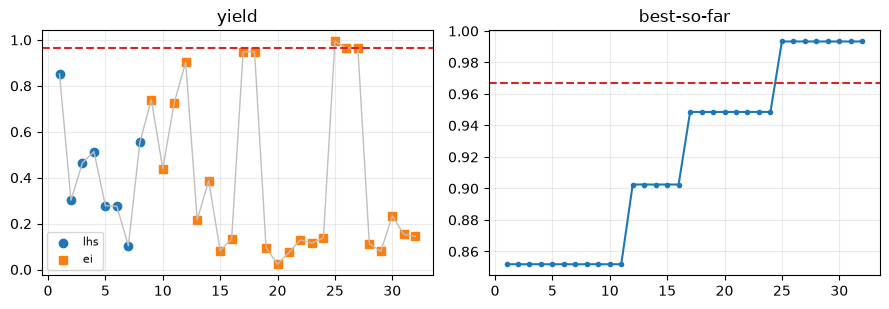

In [6]:
h = history.assign(
    step=np.arange(1, len(history) + 1),
    best_so_far=history["yield"].cummax(),
)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
for src, m in ("lhs", "o"), ("ei", "s"):
    s = h[h.source == src]; ax[0].scatter(s.step, s["yield"], marker=m, label=src)
ax[0].plot(h.step, h["yield"], c="0.75", lw=1)
ax[0].axhline(y_star, ls="--", c="C3"); ax[0].legend(fontsize=8); ax[0].set_title("yield")
ax[1].plot(h.step, h.best_so_far, "-o", ms=3); ax[1].axhline(y_star, ls="--", c="C3"); ax[1].set_title("best-so-far")
for a in ax: a.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(DATA / "plots.png", dpi=140); plt.show()